In [2]:
"""

Ilustrating the CMP / Ilustrando o PMC

Author / Autor: imoripaolo

"""

import numpy as np
import matplotlib.pyplot as plt
import math as math

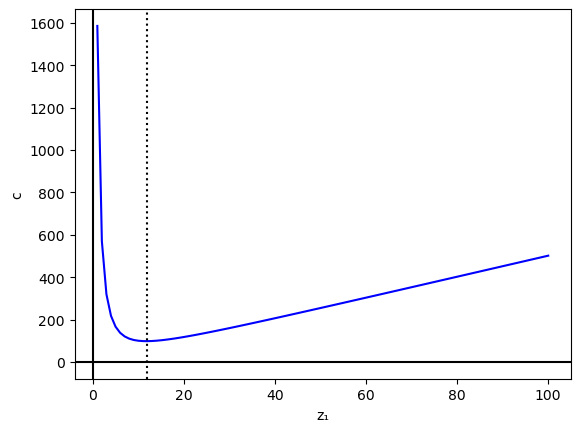

As Demandas Compensadas são z₁(q,w)= 12.0 e z₂(q,w)= 7.607257743127309


In [5]:
"""
The Cost Minimization Problem

min_{z_1,z_2} z_1w_1 + z_2w_2 st f(z_1,z_2) = q

We assume a Cobb-Douglas function:

q = z_1^{alpha_1}z_2^{alpha_2}

Therefore,

z_2 = (q/z_1^{alpha_1})^{1/alpha_2}

Therefore, we can write the CMP as:

min_{z_1} z_1w_1 + (q/z_1^{alpha_1})^{1/alpha_2}w_2

Method: Grid search

-----

O Problema de Minimização de Custos

min_{z_1,z_2} z_1w_1 + z_2w_2 st f(z_1,z_2) = q

Assumimos uma função Cobb-Douglas

q = z_1^{alpha_1}z_2^{alpha_2}

Logo,

z_2 = (q/z_1^{alpha_1})^{1/alpha_2}

Então, podemos escrever o PMC como:

min_{z_1} z_1w_1 + (q/z_1^{alpha_1})^{1/alpha_2}w_2

Método: procura no grid

"""

q, w1, w2 = 10, 5, 5

def cost(x,y):
    c = (x*w1) + (y*w2)
    return c

z1_min, z1_max = 1, 100
z1 = np.linspace(z1_min, z1_max, 100)
 

c = np.zeros(100)
for i in range(0,100):
    c[i] = cost(z1[i],((q**(1/0.4))/(z1[i]**(0.6/0.4))))

star = np.argmin(c)

fig, ax = plt.subplots()
ax.plot(z1, c,'b')
ax.set_ylabel('c')
ax.set_xlabel('z\u2081')
plt.axhline(y=0, color='black')
plt.axvline(x=0, color='black')
plt.axvline(x=z1[star], color='black', linestyle = 'dotted')
plt.show()


print("As Demandas Compensadas são z\u2081(q,w)=", z1[star], "e z\u2082(q,w)=", (q/z1[star]**0.6)**(1/0.4) )    

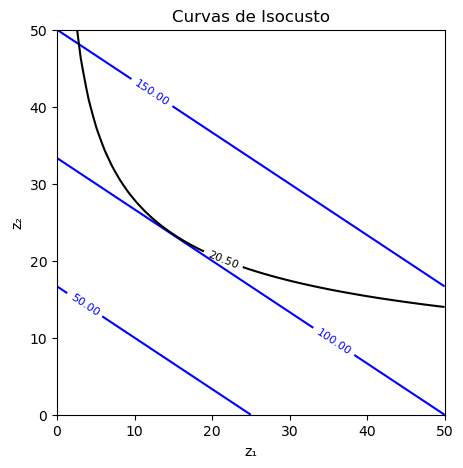

In [8]:
# Now let's check the traditional graph / Agora vamos ver o nosso gráfico tradicional:

def tech(x,y):
    output = (x**0.3)*(y**0.7)
    return output

def cost(x,y):
    output = 2*x + 3*y
    return output

z1 = np.linspace(0,50, 50)
z2 = np.linspace(0,50, 50)
X, Y = np.meshgrid(z1, z2)

Q = tech(X, Y)
C = cost(X,Y) 


plt.figure(figsize=(5, 5))
prod = plt.contour(X, Y, C, levels=[50,100,150],  colors='blue')
cost = plt.contour(X, Y, Q, levels=[20.5], colors='black')
plt.clabel(prod, inline=True, fontsize=8, fmt='%.2f')
plt.clabel(cost, inline=True, fontsize=8, fmt='%.2f')
plt.title('Curvas de Isocusto')
plt.xlabel('z\u2081')
plt.ylabel('z\u2082')
#plt.grid(True, linestyle='--', alpha=0.5)
plt.show()